# WalSmart - Targeted Marketing

### Project Notebook 4 - Test pipeline annex
Margarida Sardinha | 20221959

Master's in Information Management - Data Mining I

## Table of Contents

1. [Imports](#imports)
2. [Data Preparation](#data-preparation)
3. [Micro-Clustering: HDBSCAN](#micro-clustering)
4. [Macro-Clustering: Microcluster Aggregation](#macro-clustering)
5. [Visualization](#visualization)
6. [Output Results](#output-results)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
import hdbscan
import seaborn as sns

from src.preproc import *
from src.modelling import *

c:\Users\msard\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Preparation

In [2]:
# Load and preprocess data
raw_data = pd.read_csv('NOVAIMS_projectData_B2C_202526.csv')
preproc_data = walsmart_preproc(raw_data)
scaled_data = walsmart_scaling(preproc_data)

In [3]:
# Remove noise points
scaled_data_clean, preproc_data_clean = pca_dbscan_noise_removal(scaled_data, preproc_data)
print(f"Data shape after noise removal: {scaled_data_clean.shape}")

Original dims: 27
PCA dims: 20
Explained variance: 0.9543
Estimated eps (95th percentile): 3.0992
Noise detected: 4721 (3.84%)
Data shape after noise removal: (118082, 28)


## 3. Micro-Clustering: HDBSCAN

### 3.1. Prepare Data and Apply PCA

In [4]:
# Prepare data: separate ID column and features
ids, X = prepare_data(scaled_data_clean, id_column='ID_Client')

# Apply PCA for dimensionality reduction
X_pca, pca = apply_pca(X, n_components=0.95)
print(f"Original shape: {X.shape}")
print(f"PCA shape: {X_pca.shape}")

PCA reduced dimensionality from 27 → 19
Original shape: (118082, 27)
PCA shape: (118082, 19)


### 3.2. UMAP for Visualization

In [5]:
# Apply UMAP for 2D visualization
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_pca)
print(f"UMAP shape: {X_umap.shape}")

c:\Users\msard\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (118082, 2)


### 3.3. HDBSCAN Micro-Clustering

In [6]:
# Apply HDBSCAN for micro-clustering on PCA-reduced data
clusterer = hdbscan.HDBSCAN(min_cluster_size=100, cluster_selection_method='eom')
micro_labels = clusterer.fit_predict(X_pca)

n_microclusters = len(set(micro_labels)) - (1 if -1 in micro_labels else 0)
n_noise = (micro_labels == -1).sum()

print(f"HDBSCAN found {n_microclusters} microclusters")
print(f"Noise points: {n_noise} ({n_noise/len(micro_labels)*100:.1f}%)")

HDBSCAN found 6 microclusters
Noise points: 1028 (0.9%)


## 4. Macro-Clustering: Microcluster Aggregation

### 4.1. Compute Microcluster Centroids

In [7]:
# Create dataframe for clustering analysis
cluster_df = pd.DataFrame({
    'ID_Client': ids,
    'Micro_Cluster': micro_labels
})

# Compute centroids of each microcluster in PCA space
microcluster_centroids = []
microcluster_ids = []

for cluster_id in sorted(set(micro_labels)):
    if cluster_id == -1:  # Skip noise
        continue
    mask = micro_labels == cluster_id
    centroid = X_pca[mask].mean(axis=0)
    microcluster_centroids.append(centroid)
    microcluster_ids.append(cluster_id)

microcluster_centroids = np.array(microcluster_centroids)
print(f"Microcluster centroids shape: {microcluster_centroids.shape}")
print(f"Number of microclusters: {len(microcluster_ids)}")

Microcluster centroids shape: (6, 19)
Number of microclusters: 6


### 4.2. Hierarchical Clustering on Centroids for Macro-Clusters

In [8]:
from sklearn.cluster import AgglomerativeClustering

# Apply hierarchical clustering to microcluster centroids
desired_macroclusters = 8
n_macroclusters = min(desired_macroclusters, len(microcluster_ids))  # Ensure not more than available microclusters

if n_macroclusters < desired_macroclusters:
    print(f"Warning: Only {len(microcluster_ids)} microclusters available. Creating {n_macroclusters} macro-clusters instead of {desired_macroclusters}.")

macro_clusterer = AgglomerativeClustering(n_clusters=n_macroclusters, linkage='ward')
macro_labels = macro_clusterer.fit_predict(microcluster_centroids)

print(f"Created {n_macroclusters} macro-clusters from {len(microcluster_ids)} microclusters")

# Create mapping from microcluster to macrocluster
micro_to_macro = {mid: mlabel for mid, mlabel in zip(microcluster_ids, macro_labels)}
print(f"Micro-to-Macro mapping created: {len(micro_to_macro)} entries")

Created 6 macro-clusters from 6 microclusters
Micro-to-Macro mapping created: 6 entries


### 4.3. Assign Macro-Clusters to Customers

In [9]:
# Map macro-cluster labels to each customer
macro_labels_full = np.full(len(micro_labels), -1, dtype=int)
for i, micro_label in enumerate(micro_labels):
    if micro_label in micro_to_macro:
        macro_labels_full[i] = micro_to_macro[micro_label]

cluster_df['Macro_Cluster'] = macro_labels_full

# Display distribution
print("\nMacro-cluster distribution:")
print(cluster_df['Macro_Cluster'].value_counts().sort_index())


Macro-cluster distribution:
Macro_Cluster
-1      1028
 0    101571
 1      2930
 2      6152
 3       215
 4      5138
 5      1048
Name: count, dtype: int64


## 5. Visualization

### 5.1. UMAP Visualization of Micro-Clusters

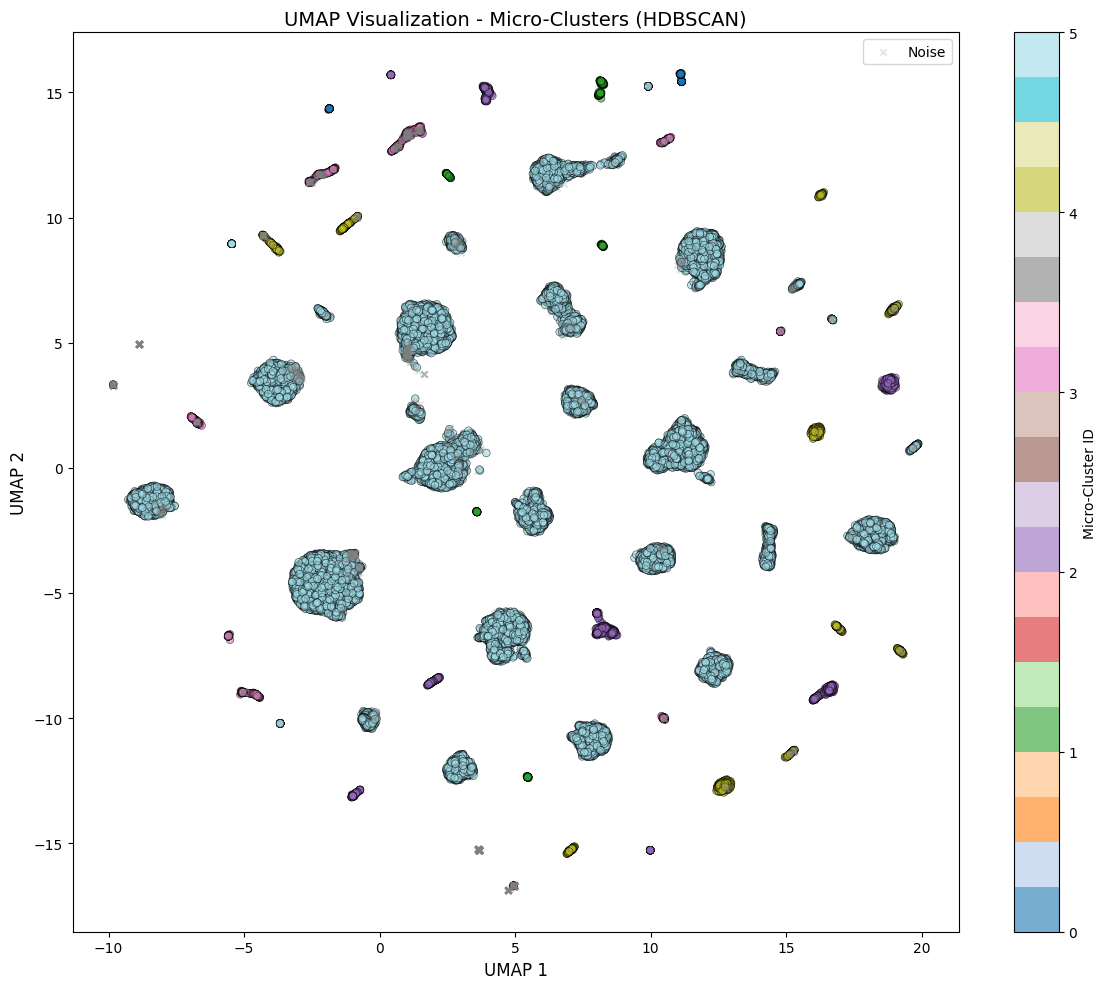

In [10]:
plt.figure(figsize=(12, 10))

# Plot non-noise points colored by microcluster
mask = micro_labels != -1
scatter = plt.scatter(
    X_umap[mask, 0], X_umap[mask, 1],
    c=micro_labels[mask], cmap='tab20', s=30, alpha=0.6, edgecolors='black', linewidth=0.5
)

# Plot noise points
if mask.sum() < len(micro_labels):
    plt.scatter(
        X_umap[~mask, 0], X_umap[~mask, 1],
        c='gray', s=20, alpha=0.2, marker='x', label='Noise'
    )

plt.colorbar(scatter, label='Micro-Cluster ID')
plt.xlabel('UMAP 1', fontsize=12)
plt.ylabel('UMAP 2', fontsize=12)
plt.title('UMAP Visualization - Micro-Clusters (HDBSCAN)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

### 5.2. UMAP Visualization of Macro-Clusters

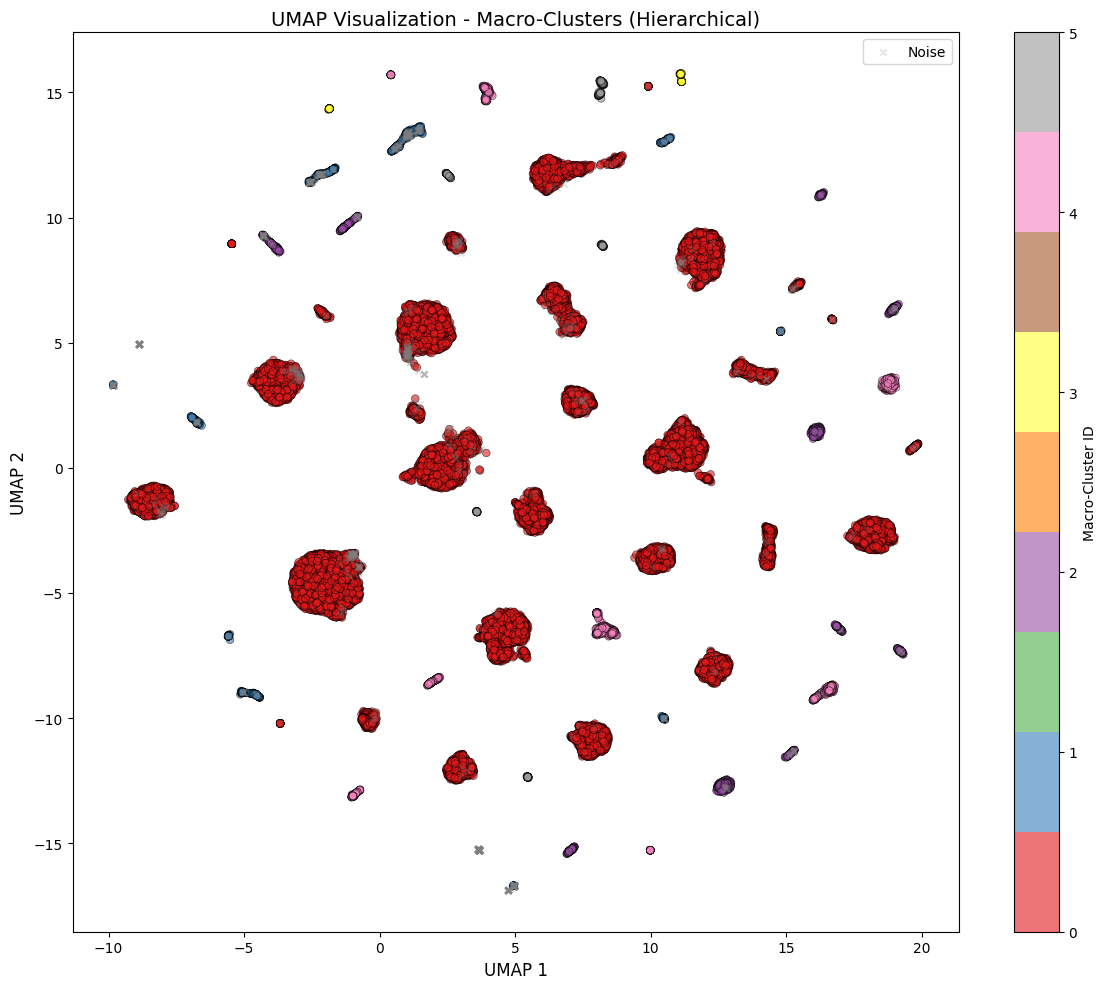

In [11]:
plt.figure(figsize=(12, 10))

# Plot non-noise points colored by macrocluster
mask = macro_labels_full != -1
scatter = plt.scatter(
    X_umap[mask, 0], X_umap[mask, 1],
    c=macro_labels_full[mask], cmap='Set1', s=30, alpha=0.6, edgecolors='black', linewidth=0.5
)

# Plot noise points
if mask.sum() < len(macro_labels_full):
    plt.scatter(
        X_umap[~mask, 0], X_umap[~mask, 1],
        c='gray', s=20, alpha=0.2, marker='x', label='Noise'
    )

plt.colorbar(scatter, label='Macro-Cluster ID')
plt.xlabel('UMAP 1', fontsize=12)
plt.ylabel('UMAP 2', fontsize=12)
plt.title('UMAP Visualization - Macro-Clusters (Hierarchical)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Output Results

In [12]:
# Merge results with original data for profiling
results_df = preproc_data_clean.merge(cluster_df, on='ID_Client', how='left')

# Compute cluster profiles
numeric_cols = results_df.select_dtypes(include=['number']).columns.tolist()
if 'ID_Client' in numeric_cols:
    numeric_cols.remove('ID_Client')

macro_profiles = results_df.groupby('Macro_Cluster')[numeric_cols].mean().round(2)

print("\nMacro-Cluster Profiles (Unscaled Data):")
print(macro_profiles)


Macro-Cluster Profiles (Unscaled Data):
               Frequency_items  Longevity_months  Recency_in_weeks  Flaged  \
Macro_Cluster                                                                
-1                       41.47             15.77              8.35    0.02   
 0                       38.12             13.62             11.39    0.00   
 1                       39.76             15.18             11.61    0.00   
 2                       38.53             13.86             11.76    0.03   
 3                       41.31             16.03             11.27    0.00   
 4                       37.75             17.65             11.32    0.00   
 5                       37.84             13.98             11.43    0.00   

               Promotional_percentage   Beer  Bottled_Water  Bread   Meat  \
Macro_Cluster                                                               
-1                              30.12  79.21          54.51  86.22  78.71   
 0                       

In [13]:
# Save results to CSV
macro_profiles.to_csv('outputs/Macro_Cluster_Profiles.csv')

print("\nResults saved:")
print("- outputs/Macro_Cluster_Profiles.csv (cluster mean profiles)")


Results saved:
- outputs/clustering_results.csv (customer IDs with cluster assignments)
- outputs/Macro_Cluster_Profiles.csv (cluster mean profiles)
